# Jacobian Accuracy Test for Sobol Disperser

This notebook validates that a Jacobian-based linear approximation can accurately predict
the dispersion mapping within cells, which is a prerequisite for the Sobol-based disperser algorithm.

**Algorithm under test:**
1. For a cell with center at (x, y, λ), compute the full dispersion solution: (x', y') = trace(x, y, λ)
2. Compute the Jacobian J = ∂(x', y')/∂(x, y, λ) at the center (a 2×3 matrix)
3. For a point at (x + dx, y + dy, λ + dλ), approximate: (x', y') ≈ trace(center) + J @ [dx, dy, dλ]

**Test parameters:**
- Cell size: 10 × 10 SCA pixels × 100Å (0.01 μm)
- x, y range: -500 to 5500 SCA pixels
- λ range: 0.9 to 2.0 μm
- All 18 SCAs, orders "0", "1", "2"
- ~1000 random cells sampled per (SCA, order) combination

**Success criteria:**
- Max error < 0.1 pixel (acceptable)
- Target: < 0.01 pixel for science-quality work

In [1]:
# Imports
import os
from pathlib import Path
import time
import json

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj

# Use larger fonts for better readability
plt.rcParams['font.size'] = 11

print(f"JAX backend: {jax.default_backend()}")
print(f"JAX devices: {jax.devices()}")

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]


## Configuration

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Cell size for Jacobian test
CELL_SIZE_X = 10.0       # SCA pixels
CELL_SIZE_Y = 10.0       # SCA pixels
CELL_SIZE_LAM = 0.01     # microns (100 Angstrom)

# Sampling ranges
X_MIN, X_MAX = -500.0, 5500.0    # SCA pixels
Y_MIN, Y_MAX = -500.0, 5500.0    # SCA pixels
LAM_MIN, LAM_MAX = 0.9, 2.0      # microns

# Number of random cells to sample per (SCA, order)
N_SAMPLES = 1000

# SCAs and orders to test
SCAS = list(range(1, 19))  # All 18 SCAs
ORDERS = ["0", "1", "2"]

# Random seed for reproducibility
RANDOM_SEED = 42

print(f"Configuration:")
print(f"  Cell size: {CELL_SIZE_X}×{CELL_SIZE_Y} pixels × {CELL_SIZE_LAM*1e4:.0f} Å")
print(f"  X range: [{X_MIN}, {X_MAX}] SCA pixels")
print(f"  Y range: [{Y_MIN}, {Y_MAX}] SCA pixels")
print(f"  λ range: [{LAM_MIN}, {LAM_MAX}] μm")
print(f"  Samples per (SCA, order): {N_SAMPLES}")
print(f"  Total configurations: {len(SCAS)} SCAs × {len(ORDERS)} orders = {len(SCAS) * len(ORDERS)}")

Configuration:
  Cell size: 10.0×10.0 pixels × 100 Å
  X range: [-500.0, 5500.0] SCA pixels
  Y range: [-500.0, 5500.0] SCA pixels
  λ range: [0.9, 2.0] μm
  Samples per (SCA, order): 1000
  Total configurations: 18 SCAs × 3 orders = 54


## Load Optical Model

In [3]:
# Load optical model
project_root = Path(os.environ["PIXI_PROJECT_ROOT"])
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"

model = RomanOpticalModel(config_file=str(config_path))
print(f"Loaded optical model from {config_path.name}")
print(f"  Pixel scale: {model.detmod['pixel_scale']} arcsec/pixel")
print(f"  Detector size: {model.detmod['naxis1']}×{model.detmod['naxis2']} pixels")
print(f"  Wavelength range: {model.wl_min:.2f}-{model.wl_max:.2f} microns")

Loaded optical model from Roman_grism_OpticalModel_v0.8.yaml
  Pixel scale: 0.11 arcsec/pixel
  Detector size: 4088×4088 pixels
  Wavelength range: 0.90-2.00 microns


## Step 1: Define the SCA-to-SCA Trace Function

The module provides `omj.trace_sca_to_sca(payload, xsca, ysca, wavelength)` which computes the full dispersion: (xsca, ysca, λ) → (xsca', ysca').

For Jacobian computation, we need the output as a stacked array, so we define a thin wrapper.

In [4]:
def trace_sca_to_sca_stacked(payload, xsca, ysca, wavelength):
    """Wrapper that returns stacked [2, n] output for Jacobian computation.
    
    Args:
        payload: dict from make_sca_payload
        xsca, ysca: SCA coordinates [n] in FITS 1-indexed pixels
        wavelength: wavelength(s) [n] in microns
        
    Returns:
        stacked array [2, n] of (xsca_out, ysca_out)
    """
    xsca_out, ysca_out = omj.trace_sca_to_sca(payload, xsca, ysca, wavelength)
    return jnp.stack([xsca_out, ysca_out])


# Test the function
test_payload = omj.make_sca_payload(model, sca=1, order="1")
test_result = trace_sca_to_sca_stacked(
    test_payload,
    jnp.array([2000.0]),
    jnp.array([2000.0]),
    jnp.array([1.5])
)
print(f"Test trace: input (2000, 2000, 1.5μm) → output ({test_result[0, 0]:.2f}, {test_result[1, 0]:.2f})")

Test trace: input (2000, 2000, 1.5μm) → output (1992.77, 1919.35)


## Step 2: Compute the Full Jacobian

Use `jax.jacobian` to compute the 2×3 Jacobian matrix ∂(xsca', ysca')/∂(xsca, ysca, λ)

In [5]:
def compute_jacobian_at_point(payload, xsca, ysca, wavelength):
    """Compute 2x3 Jacobian at a single point.
    
    Args:
        payload: dict from make_sca_payload
        xsca, ysca: scalar SCA coordinates
        wavelength: scalar wavelength in microns
        
    Returns:
        J: [2, 3] Jacobian matrix
    """
    def trace_single(inputs):
        # inputs = [xsca, ysca, wavelength]
        return trace_sca_to_sca_stacked(
            payload,
            inputs[0:1], inputs[1:2], inputs[2:3]
        ).squeeze()

    inputs = jnp.array([xsca, ysca, wavelength])
    J = jax.jacobian(trace_single)(inputs)  # [2, 3]
    return J


# Test the Jacobian computation
J_test = compute_jacobian_at_point(test_payload, 2000.0, 2000.0, 1.5)
print(f"Jacobian at (2000, 2000, 1.5μm):")
print(f"  ∂x'/∂x = {J_test[0, 0]:.4f}, ∂x'/∂y = {J_test[0, 1]:.4f}, ∂x'/∂λ = {J_test[0, 2]:.2f} pix/μm")
print(f"  ∂y'/∂x = {J_test[1, 0]:.4f}, ∂y'/∂y = {J_test[1, 1]:.4f}, ∂y'/∂λ = {J_test[1, 2]:.2f} pix/μm")

Jacobian at (2000, 2000, 1.5μm):
  ∂x'/∂x = 0.9807, ∂x'/∂y = -0.0032, ∂x'/∂λ = -6.34 pix/μm
  ∂y'/∂x = -0.0030, ∂y'/∂y = 0.9995, ∂y'/∂λ = 913.38 pix/μm


## Step 3: Define Corner Offsets

For a cell of size (10, 10, 0.01), the 8 corners are at ±(5, 5, 0.005) from the center.

In [6]:
# Define corner offsets for the 8 corners of the 3D cell
CORNER_OFFSETS = jnp.array([
    [-CELL_SIZE_X/2, -CELL_SIZE_Y/2, -CELL_SIZE_LAM/2],
    [-CELL_SIZE_X/2, -CELL_SIZE_Y/2, +CELL_SIZE_LAM/2],
    [-CELL_SIZE_X/2, +CELL_SIZE_Y/2, -CELL_SIZE_LAM/2],
    [-CELL_SIZE_X/2, +CELL_SIZE_Y/2, +CELL_SIZE_LAM/2],
    [+CELL_SIZE_X/2, -CELL_SIZE_Y/2, -CELL_SIZE_LAM/2],
    [+CELL_SIZE_X/2, -CELL_SIZE_Y/2, +CELL_SIZE_LAM/2],
    [+CELL_SIZE_X/2, +CELL_SIZE_Y/2, -CELL_SIZE_LAM/2],
    [+CELL_SIZE_X/2, +CELL_SIZE_Y/2, +CELL_SIZE_LAM/2],
])  # [8, 3]

print(f"Corner offsets (8 corners of 3D cell):")
print(f"  dx: ±{CELL_SIZE_X/2:.1f} pixels")
print(f"  dy: ±{CELL_SIZE_Y/2:.1f} pixels")
print(f"  dλ: ±{CELL_SIZE_LAM/2*1e4:.0f} Å")

Corner offsets (8 corners of 3D cell):
  dx: ±5.0 pixels
  dy: ±5.0 pixels
  dλ: ±50 Å


## Step 4: Measure Error for a Single Cell

For each cell, compute the maximum error between the full solution and Jacobian approximation at all 8 corners.

In [7]:
def measure_cell_error(payload, xc, yc, lamc, corner_offsets):
    """Compute max Jacobian approximation error at cell corners.
    
    Args:
        payload: dict from make_sca_payload
        xc, yc: cell center SCA coordinates (scalars)
        lamc: cell center wavelength (scalar)
        corner_offsets: [8, 3] array of corner offsets
        
    Returns:
        max_error: maximum Euclidean error in output pixels
    """
    # Get center output position
    center_out = trace_sca_to_sca_stacked(
        payload, 
        jnp.array([xc]), 
        jnp.array([yc]), 
        jnp.array([lamc])
    ).squeeze()  # [2]

    # Compute Jacobian at center
    J = compute_jacobian_at_point(payload, xc, yc, lamc)  # [2, 3]

    # Compute errors at all corners
    max_error = 0.0
    for offset in corner_offsets:
        # Full solution at corner
        corner_x = xc + offset[0]
        corner_y = yc + offset[1]
        corner_lam = lamc + offset[2]
        
        full_out = trace_sca_to_sca_stacked(
            payload,
            jnp.array([corner_x]),
            jnp.array([corner_y]),
            jnp.array([corner_lam])
        ).squeeze()  # [2]

        # Jacobian approximation
        approx_out = center_out + J @ offset

        # Error (Euclidean distance in output pixels)
        error = jnp.sqrt(jnp.sum((full_out - approx_out)**2))
        max_error = jnp.maximum(max_error, error)

    return max_error


# Test error measurement
test_error = measure_cell_error(test_payload, 2000.0, 2000.0, 1.5, CORNER_OFFSETS)
print(f"Test cell error at (2000, 2000, 1.5μm): {float(test_error):.6f} pixels")

Test cell error at (2000, 2000, 1.5μm): 0.000440 pixels


## Step 5: Vectorize with vmap

Create a JIT-compiled vectorized version for efficient computation over many cells.

In [8]:
def make_vectorized_error_fn(payload):
    """Create a JIT-compiled vectorized error function for a specific payload.
    
    Uses closure pattern to capture payload (which contains non-traceable strings).
    """
    @jax.jit
    def measure_many_errors(x_arr, y_arr, lam_arr):
        """Compute errors for arrays of cell centers."""
        def single_error(x, y, lam):
            return measure_cell_error(payload, x, y, lam, CORNER_OFFSETS)
        return jax.vmap(single_error)(x_arr, y_arr, lam_arr)
    
    return measure_many_errors


# Test vectorized version
test_fn = make_vectorized_error_fn(test_payload)
test_x = jnp.array([1000.0, 2000.0, 3000.0])
test_y = jnp.array([1000.0, 2000.0, 3000.0])
test_lam = jnp.array([1.2, 1.5, 1.8])

t0 = time.time()
test_errors = test_fn(test_x, test_y, test_lam)
test_errors.block_until_ready()
t1 = time.time()

print(f"Vectorized test (3 points):")
for i in range(3):
    print(f"  ({test_x[i]:.0f}, {test_y[i]:.0f}, {test_lam[i]:.1f}μm) → error = {test_errors[i]:.6f} pix")
print(f"  Time (first call, includes JIT): {t1-t0:.3f}s")

# Second call should be faster
t0 = time.time()
test_errors2 = test_fn(test_x, test_y, test_lam)
test_errors2.block_until_ready()
t1 = time.time()
print(f"  Time (cached call): {t1-t0:.3f}s")

Vectorized test (3 points):
  (1000, 1000, 1.2μm) → error = 0.000492 pix
  (2000, 2000, 1.5μm) → error = 0.000273 pix
  (3000, 3000, 1.8μm) → error = 0.000546 pix
  Time (first call, includes JIT): 0.332s
  Time (cached call): 0.000s


## Step 6: Run Validation for Single SCA/Order

First, validate on a single (SCA, order) combination to ensure the approach works.

In [9]:
# Generate random cell centers
np.random.seed(RANDOM_SEED)
x_samples = np.random.uniform(X_MIN, X_MAX, N_SAMPLES).astype(np.float32)
y_samples = np.random.uniform(Y_MIN, Y_MAX, N_SAMPLES).astype(np.float32)
lam_samples = np.random.uniform(LAM_MIN, LAM_MAX, N_SAMPLES).astype(np.float32)

print(f"Generated {N_SAMPLES} random cell centers")
print(f"  x range: [{x_samples.min():.1f}, {x_samples.max():.1f}]")
print(f"  y range: [{y_samples.min():.1f}, {y_samples.max():.1f}]")
print(f"  λ range: [{lam_samples.min():.3f}, {lam_samples.max():.3f}]")

Generated 1000 random cell centers
  x range: [-472.2, 5498.3]
  y range: [-480.7, 5496.5]
  λ range: [0.900, 1.998]


In [10]:
# Test on SCA 1, order "1"
test_sca = 1
test_order = "1"

print(f"\nValidating SCA {test_sca}, order {test_order}...")

payload = omj.make_sca_payload(model, sca=test_sca, order=test_order)
error_fn = make_vectorized_error_fn(payload)

# Convert to JAX arrays
x_jax = jnp.array(x_samples)
y_jax = jnp.array(y_samples)
lam_jax = jnp.array(lam_samples)

# Run computation
t0 = time.time()
errors = error_fn(x_jax, y_jax, lam_jax)
errors.block_until_ready()
t1 = time.time()

# Convert to numpy for statistics
errors_np = np.array(errors)

print(f"\nResults for SCA {test_sca}, order {test_order}:")
print(f"  Computation time: {t1-t0:.2f}s")
print(f"  Max error: {errors_np.max():.6f} pixels")
print(f"  Mean error: {errors_np.mean():.6f} pixels")
print(f"  Median error: {np.median(errors_np):.6f} pixels")
print(f"  95th percentile: {np.percentile(errors_np, 95):.6f} pixels")
print(f"  99th percentile: {np.percentile(errors_np, 99):.6f} pixels")

# Find worst case
worst_idx = np.argmax(errors_np)
print(f"\n  Worst case cell:")
print(f"    Position: ({x_samples[worst_idx]:.1f}, {y_samples[worst_idx]:.1f}, {lam_samples[worst_idx]:.4f}μm)")
print(f"    Error: {errors_np[worst_idx]:.6f} pixels")


Validating SCA 1, order 1...

Results for SCA 1, order 1:
  Computation time: 0.35s
  Max error: 0.002072 pixels
  Mean error: 0.000770 pixels
  Median error: 0.000691 pixels
  95th percentile: 0.001468 pixels
  99th percentile: 0.001661 pixels

  Worst case cell:
    Position: (4613.1, 3109.7, 1.0221μm)
    Error: 0.002072 pixels


## Step 7: Visualize Error Distribution

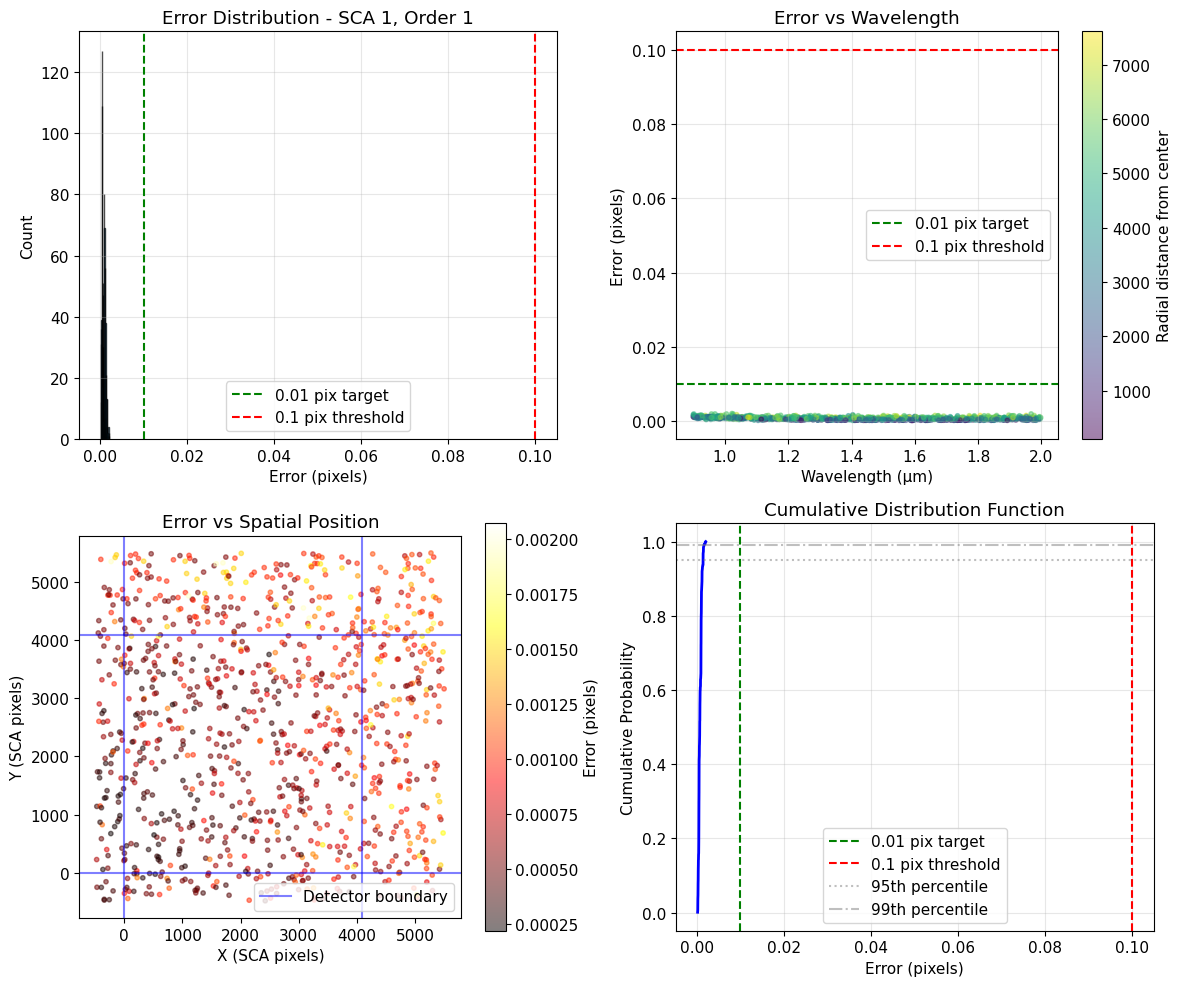

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histogram of errors
ax = axes[0, 0]
ax.hist(errors_np, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0.01, color='g', linestyle='--', label='0.01 pix target')
ax.axvline(0.1, color='r', linestyle='--', label='0.1 pix threshold')
ax.set_xlabel('Error (pixels)')
ax.set_ylabel('Count')
ax.set_title(f'Error Distribution - SCA {test_sca}, Order {test_order}')
ax.legend()
ax.grid(alpha=0.3)

# Error vs wavelength
ax = axes[0, 1]
scatter = ax.scatter(lam_samples, errors_np, c=np.sqrt(x_samples**2 + y_samples**2), 
                     alpha=0.5, s=10, cmap='viridis')
ax.axhline(0.01, color='g', linestyle='--', label='0.01 pix target')
ax.axhline(0.1, color='r', linestyle='--', label='0.1 pix threshold')
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Error (pixels)')
ax.set_title('Error vs Wavelength')
ax.legend()
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Radial distance from center')

# Error heatmap in x-y (averaged)
ax = axes[1, 0]
scatter = ax.scatter(x_samples, y_samples, c=errors_np, 
                     alpha=0.5, s=10, cmap='hot')
ax.set_xlabel('X (SCA pixels)')
ax.set_ylabel('Y (SCA pixels)')
ax.set_title('Error vs Spatial Position')
ax.set_aspect('equal')
# Draw detector boundary
ax.axhline(0.5, color='blue', linestyle='-', alpha=0.5)
ax.axhline(4088.5, color='blue', linestyle='-', alpha=0.5)
ax.axvline(0.5, color='blue', linestyle='-', alpha=0.5)
ax.axvline(4088.5, color='blue', linestyle='-', alpha=0.5, label='Detector boundary')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Error (pixels)')

# CDF of errors
ax = axes[1, 1]
sorted_errors = np.sort(errors_np)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
ax.plot(sorted_errors, cdf, 'b-', linewidth=2)
ax.axvline(0.01, color='g', linestyle='--', label='0.01 pix target')
ax.axvline(0.1, color='r', linestyle='--', label='0.1 pix threshold')
ax.axhline(0.95, color='gray', linestyle=':', alpha=0.5, label='95th percentile')
ax.axhline(0.99, color='gray', linestyle='-.', alpha=0.5, label='99th percentile')
ax.set_xlabel('Error (pixels)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Cumulative Distribution Function')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8: Run Validation Across All SCAs and Orders

Now run the validation across all 18 SCAs and 3 orders.

In [12]:
# Storage for results
all_results = []

print("Running validation across all SCAs and orders...")
print("="*60)

total_configs = len(SCAS) * len(ORDERS)
config_idx = 0

for sca in SCAS:
    for order in ORDERS:
        config_idx += 1
        
        # Create payload and error function
        payload = omj.make_sca_payload(model, sca=sca, order=order)
        error_fn = make_vectorized_error_fn(payload)
        
        # Run computation
        t0 = time.time()
        errors = error_fn(x_jax, y_jax, lam_jax)
        errors.block_until_ready()
        elapsed = time.time() - t0
        
        errors_np = np.array(errors)
        
        # Find worst case
        worst_idx = np.argmax(errors_np)
        
        # Store results
        result = {
            'sca': sca,
            'order': order,
            'max_error': float(errors_np.max()),
            'mean_error': float(errors_np.mean()),
            'median_error': float(np.median(errors_np)),
            'p95_error': float(np.percentile(errors_np, 95)),
            'p99_error': float(np.percentile(errors_np, 99)),
            'worst_x': float(x_samples[worst_idx]),
            'worst_y': float(y_samples[worst_idx]),
            'worst_lam': float(lam_samples[worst_idx]),
            'time': elapsed,
        }
        all_results.append(result)
        
        # Print progress
        print(f"[{config_idx:2d}/{total_configs}] SCA {sca:2d}, order {order}: "
              f"max={errors_np.max():.4f}, p99={np.percentile(errors_np, 99):.4f} pix "
              f"({elapsed:.2f}s)")

print("="*60)
print("Validation complete!")

Running validation across all SCAs and orders...
[ 1/54] SCA  1, order 0: max=0.0020, p99=0.0015 pix (0.32s)
[ 2/54] SCA  1, order 1: max=0.0021, p99=0.0017 pix (0.33s)
[ 3/54] SCA  1, order 2: max=0.0026, p99=0.0020 pix (0.39s)
[ 4/54] SCA  2, order 0: max=0.0027, p99=0.0023 pix (0.32s)
[ 5/54] SCA  2, order 1: max=0.0027, p99=0.0021 pix (0.34s)
[ 6/54] SCA  2, order 2: max=0.0030, p99=0.0025 pix (0.33s)
[ 7/54] SCA  3, order 0: max=0.0049, p99=0.0032 pix (0.32s)
[ 8/54] SCA  3, order 1: max=0.0041, p99=0.0035 pix (0.41s)
[ 9/54] SCA  3, order 2: max=0.0055, p99=0.0043 pix (0.33s)
[10/54] SCA  4, order 0: max=0.0036, p99=0.0029 pix (0.32s)
[11/54] SCA  4, order 1: max=0.0035, p99=0.0028 pix (0.32s)
[12/54] SCA  4, order 2: max=0.0047, p99=0.0031 pix (0.33s)
[13/54] SCA  5, order 0: max=0.0038, p99=0.0027 pix (0.40s)
[14/54] SCA  5, order 1: max=0.0034, p99=0.0029 pix (0.33s)
[15/54] SCA  5, order 2: max=0.0040, p99=0.0034 pix (0.34s)
[16/54] SCA  6, order 0: max=0.0043, p99=0.0035 pix

## Step 9: Summary Statistics

In [13]:
# Overall statistics
max_errors = np.array([r['max_error'] for r in all_results])
p99_errors = np.array([r['p99_error'] for r in all_results])

print("\n" + "="*60)
print("OVERALL SUMMARY")
print("="*60)
print(f"\nAcross all {len(all_results)} (SCA, order) combinations:")
print(f"  Cell size: {CELL_SIZE_X}×{CELL_SIZE_Y} pixels × {CELL_SIZE_LAM*1e4:.0f} Å")
print(f"  Samples per config: {N_SAMPLES}")
print(f"")
print(f"  Worst max error: {max_errors.max():.6f} pixels")
print(f"  Best max error: {max_errors.min():.6f} pixels")
print(f"  Mean of max errors: {max_errors.mean():.6f} pixels")
print(f"")
print(f"  Worst 99th percentile: {p99_errors.max():.6f} pixels")
print(f"  Mean of 99th percentiles: {p99_errors.mean():.6f} pixels")

# Check against thresholds
print(f"\n" + "-"*60)
print("PASS/FAIL ASSESSMENT:")
if max_errors.max() < 0.01:
    print(f"  ✓ EXCELLENT: All errors < 0.01 pixel")
elif max_errors.max() < 0.1:
    print(f"  ✓ ACCEPTABLE: All errors < 0.1 pixel")
else:
    print(f"  ✗ WARNING: Some errors ≥ 0.1 pixel")
    # Find worst configurations
    for r in all_results:
        if r['max_error'] >= 0.1:
            print(f"    - SCA {r['sca']}, order {r['order']}: max={r['max_error']:.4f}")


OVERALL SUMMARY

Across all 54 (SCA, order) combinations:
  Cell size: 10.0×10.0 pixels × 100 Å
  Samples per config: 1000

  Worst max error: 0.007927 pixels
  Best max error: 0.002013 pixels
  Mean of max errors: 0.004651 pixels

  Worst 99th percentile: 0.005421 pixels
  Mean of 99th percentiles: 0.003553 pixels

------------------------------------------------------------
PASS/FAIL ASSESSMENT:
  ✓ EXCELLENT: All errors < 0.01 pixel


In [14]:
# Summary table by order
print("\n" + "="*60)
print("SUMMARY BY ORDER")
print("="*60)
print(f"\n{'Order':<8} {'Max Error (pix)':<18} {'Mean Max (pix)':<18} {'P99 Max (pix)'}")
print("-"*60)

for order in ORDERS:
    order_results = [r for r in all_results if r['order'] == order]
    order_max = max(r['max_error'] for r in order_results)
    order_mean_max = np.mean([r['max_error'] for r in order_results])
    order_p99_max = max(r['p99_error'] for r in order_results)
    print(f"{order:<8} {order_max:<18.6f} {order_mean_max:<18.6f} {order_p99_max:.6f}")


SUMMARY BY ORDER

Order    Max Error (pix)    Mean Max (pix)     P99 Max (pix)
------------------------------------------------------------
0        0.007927           0.004585           0.005371
1        0.007828           0.004455           0.005377
2        0.007340           0.004915           0.005421


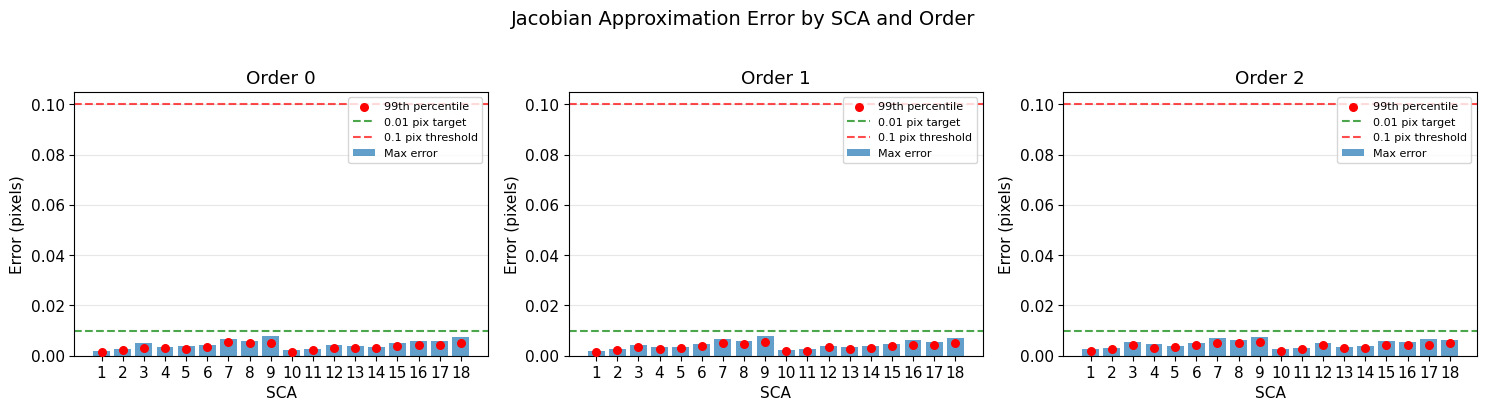

In [15]:
# Visualization: max error by SCA and order
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, order in enumerate(ORDERS):
    ax = axes[idx]
    
    order_results = [r for r in all_results if r['order'] == order]
    scas = [r['sca'] for r in order_results]
    max_errs = [r['max_error'] for r in order_results]
    p99_errs = [r['p99_error'] for r in order_results]
    
    ax.bar(scas, max_errs, alpha=0.7, label='Max error')
    ax.scatter(scas, p99_errs, color='red', marker='o', s=30, label='99th percentile', zorder=5)
    ax.axhline(0.01, color='g', linestyle='--', alpha=0.7, label='0.01 pix target')
    ax.axhline(0.1, color='r', linestyle='--', alpha=0.7, label='0.1 pix threshold')
    
    ax.set_xlabel('SCA')
    ax.set_ylabel('Error (pixels)')
    ax.set_title(f'Order {order}')
    ax.set_xticks(scas)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Jacobian Approximation Error by SCA and Order', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 10: Save Results

In [16]:
# Save results to JSON
output_file = project_root / "notebooks" / "demos" / "jacobian_accuracy_results.json"

results_summary = {
    'config': {
        'cell_size_x': CELL_SIZE_X,
        'cell_size_y': CELL_SIZE_Y,
        'cell_size_lam': CELL_SIZE_LAM,
        'x_range': [X_MIN, X_MAX],
        'y_range': [Y_MIN, Y_MAX],
        'lam_range': [LAM_MIN, LAM_MAX],
        'n_samples': N_SAMPLES,
        'random_seed': RANDOM_SEED,
    },
    'summary': {
        'worst_max_error': float(max_errors.max()),
        'best_max_error': float(max_errors.min()),
        'mean_max_error': float(max_errors.mean()),
        'worst_p99_error': float(p99_errors.max()),
    },
    'results': all_results,
}

with open(output_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"Results saved to: {output_file}")

Results saved to: /Users/np274/10-Notebook/1-Projects/roman_disperser/notebooks/demos/jacobian_accuracy_results.json


## Conclusions

Based on the results:

1. **If max error < 0.01 pixel**: The Jacobian approximation is excellent. Proceed with the Sobol disperser using 10×10×100Å cells.

2. **If max error 0.01-0.1 pixel**: The Jacobian approximation is acceptable but may need:
   - Smaller cells (e.g., 5×5×50Å)
   - Or Hessian correction for higher accuracy

3. **If max error > 0.1 pixel**: The Jacobian approximation may not be suitable. Consider:
   - Much smaller cells
   - Full solution at all points (expensive)
   - Investigate which regions have high error (edge effects, specific wavelengths)